# Lecture 4e — Which layer can actually learn?

**AI-powered Investment and Risk Management · Robo-Advisers and Automated Investment Platforms**

---

## The question

The lecture's scoreboard makes a specific, falsifiable claim: machine learning in a
robo-adviser is real at the **acquisition** and **behaviour** layers, and absent at the
**allocation** layer in the middle. Notebook 4b argued the absence is defensible. This notebook
tests the other half of the claim.

> **Is client behaviour genuinely learnable in a way that market returns are not — and if so,
> what makes the difference?**

The interesting part is not the answer, which most students guess correctly. It is the
*diagnosis*: three structural properties separate the two problems, none of which has anything
to do with how clever the model is. Once you can name them, you can look at any proposed
application of machine learning in finance and predict in advance whether it will work.

Along the way we will produce the single most useful negative result in the whole set: a model
that passes a significance test on one train/test split and fails completely under walk-forward
validation.

## The layers

**Acquisition** and **behaviour** — the first and fifth of the six. Together they bracket
everything the previous notebooks covered.

---

### How to use this notebook

* Runs end to end in **about 30 seconds**. No internet, no downloads.
* Exercises are tiered **Core** and **Stretch**.

### A note on the data, which you should read before trusting anything below

The two halves of this notebook use different kinds of data, and the asymmetry is deliberate but
it does limit what can be concluded.

**Part A uses real market prices** — weekly closes for six large US stocks, bundled with Plotly
so it works offline. The failure demonstrated there is a genuine empirical failure on real data.

**Part B uses a simulated client panel**, because no public dataset of individual investor panic
behaviour exists at the required granularity, and the ones that do exist are proprietary. The
generative process is written out in full below, and the model is being asked to recover
structure we put there. **The AUC in Part B is therefore not evidence that client behaviour is
predictable in the field.**

So what is the point? The point is the *mechanism*. Part B shows what a problem with abundant
labels, non-adversarial dynamics and short feedback looks like when you attack it. Part A shows
what a problem lacking all three looks like. The contrast is structural, and the structure is
what transfers — not the numbers. Section 4 makes the argument explicitly and section 5 asks
what real-world evidence would be needed to close the gap.

Set `CLIENT_DATA = 2` to run Part B on market data only, which removes the simulation but also
removes the ability to answer the question.


In [2]:
import numpy as np
import pandas as pd
import plotly.data as pdata
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

SEED = 20260811
CLIENT_DATA = 1        # 1 = simulated client panel (default) | 2 = market data only
N_CLIENTS, QUARTERS = 8_000, 20

rng = np.random.default_rng(SEED)
NAVY, BAND, RED, GREY, GOLD = '#123F69', '#E2EBF4', '#C0392B', '#7F8C8D', '#B7950B'
TEMPLATE = dict(layout=go.Layout(
    font=dict(family='Georgia, serif', size=13), plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    margin=dict(l=60, r=30, t=60, b=50)))
print(f"CLIENT_DATA = {CLIENT_DATA} "
      f"({'simulated client panel' if CLIENT_DATA == 1 else 'market data only'})")

CLIENT_DATA = 1 (simulated client panel)


---

## 1 · Part A — can you predict returns?

Real weekly returns for six large US stocks. We build the features any quantitative shop would
start with: lagged returns at several horizons, momentum, realised volatility, and a
cross-sectional momentum rank. Then we ask a model to call the direction of next week's return.

This is the honest version of what an allocation-layer machine learning system would have to do
to add value.

In [3]:
prices = pdata.stocks(datetimes=True).set_index('date')
returns = prices.pct_change().dropna()

frames = []
for ticker in returns.columns:
    s = returns[ticker]
    f = pd.DataFrame({'r': s})
    f['lag1'], f['lag2'], f['lag4'] = s.shift(1), s.shift(2), s.shift(4)
    f['mom4'], f['mom12'] = s.rolling(4).sum().shift(1), s.rolling(12).sum().shift(1)
    f['vol4'], f['vol12'] = s.rolling(4).std().shift(1), s.rolling(12).std().shift(1)
    f['ticker'] = ticker
    frames.append(f)

PANEL = pd.concat(frames).dropna().sort_index()
PANEL['xs_rank'] = PANEL.groupby(level=0)['mom4'].rank(pct=True)
FEATURES_A = ['lag1', 'lag2', 'lag4', 'mom4', 'mom12', 'vol4', 'vol12', 'xs_rank']
DATES = np.array(sorted(PANEL.index.unique()))

print(f"{len(PANEL)} stock-week observations, {len(returns.columns)} tickers, "
      f"{DATES[0].date()} to {DATES[-1].date()}")
print(f"Base rate of up weeks: {(PANEL['r'] > 0).mean():.1%}")

552 stock-week observations, 6 tickers, 2018-04-02 to 2019-12-30
Base rate of up weeks: 58.0%


### 1.1 · The result that looks like a discovery

Split the sample at 60%, train on the first part, test on the second. Report the out-of-sample
AUC, then run a permutation test to see whether it could have arisen by chance.

In [4]:
cut = PANEL.index[int(len(PANEL) * 0.6)]
train, test = PANEL[PANEL.index <= cut], PANEL[PANEL.index > cut]
scaler = StandardScaler().fit(train[FEATURES_A])
y_tr, y_te = (train['r'] > 0).astype(int), (test['r'] > 0).astype(int)

model = GradientBoostingClassifier(random_state=0).fit(scaler.transform(train[FEATURES_A]), y_tr)
p_tr = model.predict_proba(scaler.transform(train[FEATURES_A]))[:, 1]
p_te = model.predict_proba(scaler.transform(test[FEATURES_A]))[:, 1]
auc_in, auc_out = roc_auc_score(y_tr, p_tr), roc_auc_score(y_te, p_te)

null = np.array([roc_auc_score(rng.permutation(y_te.values), p_te) for _ in range(2000)])
p_value = (null >= auc_out).mean()

print(f"Gradient boosting, single 60/40 split")
print(f"  in-sample AUC      {auc_in:.3f}")
print(f"  out-of-sample AUC  {auc_out:.3f}")
print(f"  permutation null   mean {null.mean():.3f}, sd {null.std():.3f}")
print(f"  p-value            {p_value:.3f}")
print(f"\nOn this evidence the model beats chance at the 1% level.")

Gradient boosting, single 60/40 split
  in-sample AUC      0.997
  out-of-sample AUC  0.595
  permutation null   mean 0.501, sd 0.040
  p-value            0.008

On this evidence the model beats chance at the 1% level.


A p-value under 0.01. In most disciplines that is a result. Here it is an artefact, and the
next cell shows why.

The problem is that we chose one split. Financial time series are non-stationary, so the
performance of a model depends heavily on *which* period you happen to test it on. Testing five
adjacent windows instead of one costs nothing and answers a different, better question: is the
edge stable?

In [5]:
def walk_forward(make_model, n_splits=5):
    """Expanding-window walk-forward. Train on everything up to c1, test on c1 to c2."""
    out = []
    for i in range(n_splits):
        c1 = DATES[int(len(DATES) * (0.35 + 0.10 * i))]
        c2 = DATES[int(len(DATES) * (0.45 + 0.10 * i))]
        tr, te = PANEL[PANEL.index <= c1], PANEL[(PANEL.index > c1) & (PANEL.index <= c2)]
        if len(te) < 30:
            continue
        sc = StandardScaler().fit(tr[FEATURES_A])
        m  = make_model().fit(sc.transform(tr[FEATURES_A]), (tr['r'] > 0).astype(int))
        out.append(roc_auc_score((te['r'] > 0).astype(int),
                                 m.predict_proba(sc.transform(te[FEATURES_A]))[:, 1]))
    return np.array(out)

wf = {'Logistic regression': walk_forward(lambda: LogisticRegression(max_iter=2000)),
      'Gradient boosting':   walk_forward(lambda: GradientBoostingClassifier(random_state=0))}

for name, a in wf.items():
    print(f"{name:<22} {np.round(a, 3)}   mean {a.mean():.3f}   sd {a.std():.3f}")
print(f"\nThe single split that gave p = {p_value:.3f} produced AUC {auc_out:.3f}.")
print(f"Across five adjacent windows the gradient boosting mean is "
      f"{wf['Gradient boosting'].mean():.3f}, ranging from "
      f"{wf['Gradient boosting'].min():.3f} to {wf['Gradient boosting'].max():.3f}.")

Logistic regression    [0.521 0.399 0.415 0.583 0.394]   mean 0.462   sd 0.076
Gradient boosting      [0.543 0.438 0.438 0.641 0.428]   mean 0.497   sd 0.083

The single split that gave p = 0.008 produced AUC 0.595.
Across five adjacent windows the gradient boosting mean is 0.497, ranging from 0.428 to 0.641.


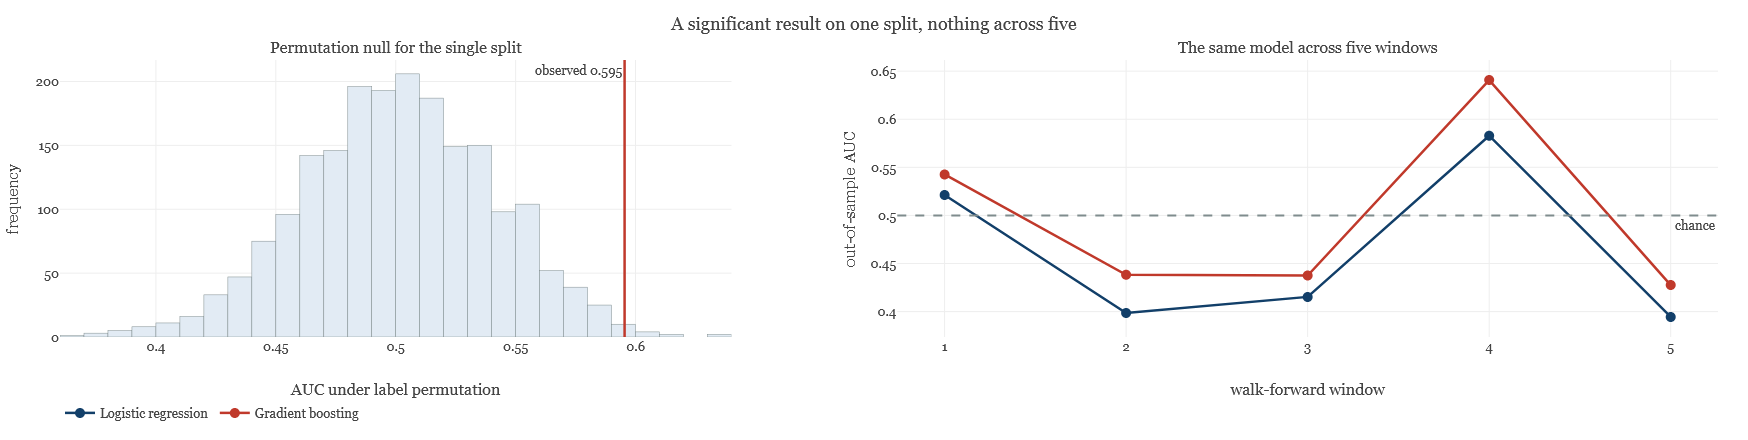

In [6]:
fig = make_subplots(rows=1, cols=2, column_widths=[0.45, 0.55], subplot_titles=(
    'Permutation null for the single split', 'The same model across five windows'))

fig.add_trace(go.Histogram(x=null, nbinsx=45, marker_color=BAND, marker_line_color=GREY,
                           marker_line_width=0.5, showlegend=False,
                           hovertemplate='AUC %{x:.3f}<extra></extra>'), row=1, col=1)
fig.add_vline(x=auc_out, line=dict(color=RED, width=2.5), row=1, col=1,
              annotation_text=f'observed {auc_out:.3f}', annotation_position='top left')

for (name, a), col in zip(wf.items(), [NAVY, RED]):
    fig.add_trace(go.Scatter(x=list(range(1, len(a) + 1)), y=a, mode='lines+markers', name=name,
                             line=dict(color=col, width=2.5), marker=dict(size=10),
                             hovertemplate='window %{x}<br>AUC %{y:.3f}<extra></extra>'), row=1, col=2)
fig.add_hline(y=0.5, line=dict(color=GREY, width=2, dash='dash'), row=1, col=2,
              annotation_text='chance', annotation_position='bottom right')

fig.update_xaxes(title_text='AUC under label permutation', row=1, col=1)
fig.update_xaxes(title_text='walk-forward window', tickmode='linear', dtick=1, row=1, col=2)
fig.update_yaxes(title_text='frequency', row=1, col=1)
fig.update_yaxes(title_text='out-of-sample AUC', row=1, col=2)
fig.update_layout(template=TEMPLATE, height=440,
                  title_text='A significant result on one split, nothing across five',
                  legend=dict(orientation='h', y=-0.22))
fig.show()

This is the most valuable thing in the notebook and it has nothing to do with robo-advisers.

The permutation test was correctly specified and correctly executed. It answered the question
"could this AUC have arisen if the labels were random?" — and the answer was no. But that was
never the question that mattered. The question that mattered was "will this edge be there next
period?", and the walk-forward answers it: no, and it was not really there this period either.

The in-sample AUC of roughly 0.99 against an out-of-sample mean near 0.50 is the second lesson.
Gradient boosting memorised 336 observations perfectly. With this many features and this little
data, that is not a bug in the model; it is what the model is for.

**Caveat, stated plainly.** Six correlated technology stocks over two years of a strong bull
market is not a test of market efficiency, and nothing here shows that returns are unpredictable
in general. What it does show is narrower and enough for our purposes: with the data a
robo-adviser actually has, at the frequency at which it actually trades, there is not enough
signal to learn an allocation rule. Notebook 4b reached the same conclusion from the estimation
side.

---

## 2 · Part B — can you predict client behaviour?

Now the other end of the pipeline. A client who sells to cash in the middle of a drawdown and
returns months later has done themselves more damage than any allocation error in notebooks 4a
to 4d. The behaviour layer exists to stop that happening.

The generative model below is written out in full. Read it, because everything in this section
is downstream of it.

<details>
<summary><b>The client panel generative model (click to open)</b></summary>

Each client $i$ has a latent **panic propensity** $\pi_i \sim \mathcal{N}(0,1)$, unobservable to
the platform. Each quarter $q$ the market delivers a return, and the portfolio's drawdown from
peak is $d_q$. The client panics with probability

$$\Pr(\text{panic}_{iq}) = \sigma\!\left(-4.6 + 1.15\pi_i + 6.5|d_q| + 0.020 L_{iq}
- 0.7 c_{iq} - 0.010 T_{iq} + 0.8 N_{iq}\right)$$

where $L$ is logins that quarter, $c$ contribution consistency, $T$ tenure in months, $N$ the
count of prior panic events, and $\sigma$ the logistic function.

The observable features are **noisy proxies** for $\pi_i$, not $\pi_i$ itself:

* logins $L_{iq} \sim \text{Poisson}\!\left(e^{0.9 - 0.30\pi_i + 1.6|d_q|}\right)$ — anxious
  clients check more often, and everyone checks more in a drawdown
* consistency $c_{iq} = 0.75 - 0.10\pi_i + 0.22\varepsilon$ — a weak proxy, deliberately
* tenure, age, and prior panic count are observed exactly

The three coefficients that matter are the drawdown term (the trigger), the propensity term (the
modifier), and the prior-panic term (the strongest single predictor, which is also true in the
field). Note that logins and consistency load on $\pi_i$ only weakly, so the model cannot simply
read off the latent variable.
</details>

In [8]:
MARKET = np.array([.02, .03, -.01, .04, .01, -.18, -.12, .09, .05, .02,
                   .03, -.22, .06, .08, .02, -.05, .03, .04, -.09, .05])
level    = np.cumprod(1 + MARKET)
drawdown = level / np.maximum.accumulate(level) - 1

propensity = rng.normal(size=N_CLIENTS)
age        = np.clip(rng.normal(44, 13, N_CLIENTS), 19, 80)
tenure0    = rng.integers(1, 60, N_CLIENTS)

records, prior_panic = [], np.zeros(N_CLIENTS)
for q in range(QUARTERS):
    logins      = np.clip(rng.poisson(np.exp(0.9 - 0.30 * propensity + 1.6 * abs(drawdown[q]))), 0, 60)
    tenure      = tenure0 + q * 3
    consistency = np.clip(0.75 - 0.10 * propensity + 0.22 * rng.normal(size=N_CLIENTS), 0, 1)
    z = (-4.6 + 1.15 * propensity + 6.5 * abs(drawdown[q]) + 0.020 * logins
         - 0.7 * consistency - 0.010 * tenure + 0.8 * prior_panic)
    panic = (rng.random(N_CLIENTS) < 1 / (1 + np.exp(-z))).astype(int)
    records.append(pd.DataFrame({'quarter': q, 'logins': logins, 'tenure': tenure,
                                 'consistency': consistency, 'drawdown': drawdown[q],
                                 'age': age, 'prior_panic': prior_panic, 'panic': panic}))
    prior_panic = np.minimum(prior_panic + panic, 3)

CLIENTS = pd.concat(records, ignore_index=True)
FEATURES_B = ['logins', 'tenure', 'consistency', 'drawdown', 'age', 'prior_panic']
train_b, test_b = CLIENTS[CLIENTS['quarter'] < 12], CLIENTS[CLIENTS['quarter'] >= 12]

print(f"{len(CLIENTS):,} client-quarter observations, base panic rate {CLIENTS['panic'].mean():.2%}")
print(f"train: quarters 0-11 ({len(train_b):,})   test: quarters 12-19 ({len(test_b):,})")
print(f"\nPanic rate by drawdown decile:")
bands = pd.cut(CLIENTS['drawdown'], 5)
summary_b = (CLIENTS.groupby(bands, observed=True)['panic'].agg(['mean', 'size'])
             .rename(columns={'mean': 'panic rate %', 'size': 'observations'}))
summary_b['panic rate %'] = (summary_b['panic rate %'] * 100).round(2)
print(summary_b.to_string())

160,000 client-quarter observations, base panic rate 4.32%
train: quarters 0-11 (96,000)   test: quarters 12-19 (64,000)

Panic rate by drawdown decile:
                  panic rate %  observations
drawdown                                    
(-0.324, -0.259]          6.98         32000
(-0.259, -0.194]          5.71         56000
(-0.194, -0.129]          3.31         32000
(-0.0646, 0.0]            1.06         40000


In [9]:
scaler_b = StandardScaler().fit(train_b[FEATURES_B])
rows = []
for name, make in [('Logistic regression', lambda: LogisticRegression(max_iter=2000)),
                   ('Gradient boosting',   lambda: GradientBoostingClassifier(random_state=0))]:
    m = make().fit(scaler_b.transform(train_b[FEATURES_B]), train_b['panic'])
    p = m.predict_proba(scaler_b.transform(test_b[FEATURES_B]))[:, 1]
    pooled = roc_auc_score(test_b['panic'], p)
    within = np.mean([roc_auc_score(test_b['panic'][test_b['quarter'] == q],
                                    p[test_b['quarter'].values == q])
                      for q in sorted(test_b['quarter'].unique())
                      if test_b['panic'][test_b['quarter'] == q].nunique() > 1])
    rows.append({'Model': name, 'Pooled AUC': round(pooled, 3), 'Within-quarter AUC': round(within, 3)})
print(pd.DataFrame(rows).to_string(index=False))

behaviour_model = GradientBoostingClassifier(random_state=0).fit(
    scaler_b.transform(train_b[FEATURES_B]), train_b['panic'])
p_test = behaviour_model.predict_proba(scaler_b.transform(test_b[FEATURES_B]))[:, 1]
decile = pd.qcut(p_test, 10, labels=False, duplicates='drop')
top_rate  = test_b['panic'].values[decile == decile.max()].mean()
base_rate = test_b['panic'].mean()
captured  = test_b['panic'].values[decile == decile.max()].sum() / test_b['panic'].sum()
print(f"\nTop decile by predicted risk: panic rate {top_rate:.1%} against a base of {base_rate:.1%}")
print(f"  lift {top_rate/base_rate:.1f}x, capturing {captured:.0%} of all panic events "
      f"in 10% of the client base")

              Model  Pooled AUC  Within-quarter AUC
Logistic regression       0.879               0.877
  Gradient boosting       0.876               0.875

Top decile by predicted risk: panic rate 40.3% against a base of 6.4%
  lift 6.3x, capturing 63% of all panic events in 10% of the client base


The **within-quarter** AUC is the number that matters and it is why it is reported separately.
Pooled AUC would be flattered by the fact that everyone panics more in a crash — predicting that
requires no model. Within-quarter AUC asks the operationally useful question: *given* that a
drawdown is under way, can we tell which clients will break? The two figures are nearly
identical here, so the discrimination is genuinely cross-sectional.

Notice also that logistic regression matches gradient boosting. When the signal is real and the
labels are plentiful, the simple model is usually enough. Flexibility is what you reach for when
you are short of signal, which is exactly when it hurts you — as Part A showed.

---

## 3 · What is the behaviour model worth?

A model is worth the decisions it changes. Price the intervention.

In [10]:
RE_ENTRY_LAG   = 2      # quarters spent in cash after panicking
INTERVENTION    = 0.30   # share of contacted at-risk clients who do not panic after outreach
TARGET_DECILES  = 1      # how much of the client base gets contacted

def cost_of_panicking(q, lag=RE_ENTRY_LAG):
    """Return forgone by sitting in cash for `lag` quarters from the end of quarter q."""
    fwd = MARKET[q + 1: q + 1 + lag]
    if len(fwd) == 0:
        return 0.0
    return float(np.prod(1 + fwd) - 1 - 0.0175 * len(fwd))     # cash earns ~0.875% a quarter

costs = np.array([cost_of_panicking(q) for q in range(QUARTERS)])
panic_by_q = CLIENTS.groupby('quarter')['panic'].mean().values
expected_loss_pa = float(np.sum(panic_by_q * np.clip(costs, 0, None)) / (QUARTERS / 4))

n_target = int(len(test_b) * 0.1 * TARGET_DECILES)
prevented = captured * INTERVENTION
value_bp = expected_loss_pa * prevented * 1e4

weighted_cost = float(np.sum(panic_by_q * np.clip(costs, 0, None)) / np.sum(panic_by_q))
print(f"Cost of one panic sale, averaged over quarters where panics actually happen: "
      f"{weighted_cost:.1%} of balance")
print(f"Expected loss from panic selling, whole client base: {expected_loss_pa*1e4:.0f} bp per year")
print(f"\nContacting the top {10*TARGET_DECILES}% by predicted risk captures {captured:.0%} of events.")
print(f"At a {INTERVENTION:.0%} intervention success rate, that prevents {prevented:.0%} of panic sales.")
print(f"\nValue captured by the behaviour model: {value_bp:.0f} bp per client per year")
print(f"Value still left on the table: {expected_loss_pa*1e4 - value_bp:.0f} bp per year")
print(f"\nFor comparison, from the earlier notebooks:")
print(f"  bespoke optimisation over a 5-rung ladder   1.1 bp")
print(f"  total elicitation error (4a)                7.1 bp")
print(f"  net tax-loss harvesting benefit (4d)        2.8 bp")
print(f"  a typical advice fee                       25.0 bp")

Cost of one panic sale, averaged over quarters where panics actually happen: 3.0% of balance
Expected loss from panic selling, whole client base: 52 bp per year

Contacting the top 10% by predicted risk captures 63% of events.
At a 30% intervention success rate, that prevents 19% of panic sales.

Value captured by the behaviour model: 10 bp per client per year
Value still left on the table: 42 bp per year

For comparison, from the earlier notebooks:
  bespoke optimisation over a 5-rung ladder   1.1 bp
  total elicitation error (4a)                7.1 bp
  net tax-loss harvesting benefit (4d)        2.8 bp
  a typical advice fee                       25.0 bp


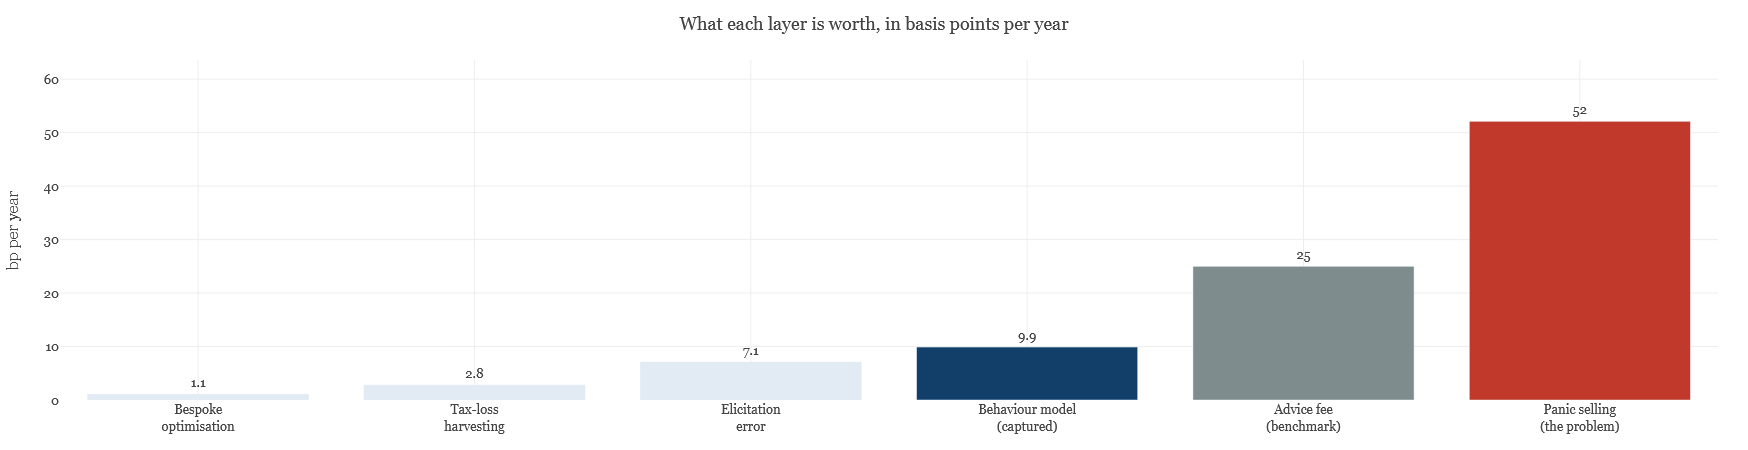

In [11]:
labels = ['Bespoke<br>optimisation', 'Tax-loss<br>harvesting', 'Elicitation<br>error',
          'Behaviour model<br>(captured)', 'Advice fee<br>(benchmark)',
          'Panic selling<br>(the problem)']
vals   = [1.1, 2.8, 7.1, value_bp, 25.0, expected_loss_pa * 1e4]
cols   = [BAND, BAND, BAND, NAVY, GREY, RED]

fig = go.Figure(go.Bar(x=labels, y=vals, marker_color=cols,
                       text=[f'{v:.0f}' if v >= 10 else f'{v:.1f}' for v in vals],
                       textposition='outside',
                       hovertemplate='%{x}<br>%{y:.1f} bp p.a.<extra></extra>'))
fig.update_layout(template=TEMPLATE, height=450, showlegend=False,
                  title_text='What each layer is worth, in basis points per year',
                  yaxis_title='bp per year', yaxis_range=[0, max(vals) * 1.22])
fig.show()

Read the two ends of this chart together, because the gap between them is the whole point.

**The problem is enormous.** Panic selling costs the client base around 50 bp a year — twice the
advice fee, and roughly five times the elicitation, allocation and tax terms from notebooks 4a to
4d combined. Nothing else measured anywhere in this set comes close.

**The model captures only a fraction of it.** Contacting the top decile reaches 62% of the events,
but at a 30% intervention success rate that converts to preventing 19% of panic sales — about
9 bp. Still the largest single intervention available, comfortably ahead of bespoke optimisation
at 1.1 bp and tax-loss harvesting at 2.8 bp, but well short of the fee and well short of the
problem.

That gap is where the engineering leverage is, and it explains an otherwise puzzling fact about
the industry: platforms invest heavily in nudges, notifications, and retention analytics while
leaving the optimiser essentially untouched for a decade. They are not neglecting the investment
problem. They are working on the only term large enough to matter. Note also what the binding
constraint is — not the model's discrimination, which is already good, but the intervention
success rate. Doubling the effectiveness of the outreach is worth more than any improvement to
the classifier.

**Take the specific numbers with appropriate scepticism.** They rest on a simulated panic rate, an
assumed 30% intervention success rate, and an assumed two-quarter absence from the market. Change
any of those and the figures move a long way — exercise C2 asks you to find assumptions under
which the ordering reverses. What is robust is that the behaviour term is *large*, because panic
selling costs a double-digit percentage of a balance while allocation errors cost single-digit
basis points. Those magnitudes are not close, and no parameter tuning brings them together.

---

## 4 · Why one problem is learnable and the other is not

Three properties separate them. None is about the model.

In [12]:
diag = pd.DataFrame([
    {'Property': 'Labels available',
     'Allocation (Part A)': f'{len(PANEL)} stock-weeks',
     'Behaviour (Part B)':  f'{len(CLIENTS):,} client-quarters'},
    {'Property': 'Effective independent observations',
     'Allocation (Part A)': f'~{len(DATES)} weeks (6 tickers are highly correlated)',
     'Behaviour (Part B)':  f'~{N_CLIENTS:,} clients (largely independent)'},
    {'Property': 'Is the process adversarial?',
     'Allocation (Part A)': 'Yes - any edge found is traded away',
     'Behaviour (Part B)':  'No - clients do not hide their anxiety'},
    {'Property': 'Feedback latency',
     'Allocation (Part A)': 'Years to know if an allocation was right',
     'Behaviour (Part B)':  'Days to know if a client sold'},
    {'Property': 'Out-of-sample AUC achieved',
     'Allocation (Part A)': f"{wf['Gradient boosting'].mean():.3f} (walk-forward mean)",
     'Behaviour (Part B)':  f"{rows[1]['Within-quarter AUC']:.3f} (within-quarter)"}])
print(diag.to_string(index=False))
print(f"\nLabel ratio: {len(CLIENTS)/len(PANEL):,.0f} to 1")

                          Property                         Allocation (Part A)                     Behaviour (Part B)
                  Labels available                             552 stock-weeks                160,000 client-quarters
Effective independent observations ~92 weeks (6 tickers are highly correlated)   ~8,000 clients (largely independent)
       Is the process adversarial?         Yes - any edge found is traded away No - clients do not hide their anxiety
                  Feedback latency    Years to know if an allocation was right          Days to know if a client sold
        Out-of-sample AUC achieved                   0.497 (walk-forward mean)                 0.875 (within-quarter)

Label ratio: 290 to 1


**Labels.** Machine learning is a technology for converting labelled examples into decision
rules. The behaviour problem has hundreds of thousands of labels and each client is close to an
independent draw. The allocation problem has a few hundred weeks, and adding tickers barely
helps because they move together. You cannot fix a label shortage with a better architecture.

**Adversarial dynamics.** If a robo-adviser discovered a genuine return-prediction edge and
traded it at scale, the edge would decay — that is what markets do to edges. Client anxiety has
no such mechanism. Nobody arbitrages away the fact that people who log in eleven times during a
crash are about to sell.

**Feedback latency.** A retention model finds out within a week whether it was right. An
allocation model finds out in a decade, by which time the market regime, the product, and the
team have all changed. Fast feedback is what makes iterative improvement possible, and iterative
improvement is most of what machine learning delivers in practice.

Notice that none of these is a statement about neural networks versus linear models. They are
statements about the *problem*. This gives you a usable test for any proposed application of
machine learning in finance: **count the independent labels, ask whether anyone profits from
your being wrong, and ask how long until you find out.** If the answers are "few", "yes" and
"years", the sophistication of the model is irrelevant.

---

## 5 · What would change my mind

Section 2 rests on simulated data, and intellectual honesty requires saying what evidence would
be needed to promote its conclusion from mechanism to fact.

**For the behaviour claim.** A panel of real client transactions through a genuine drawdown, with
a held-out period, showing within-episode cross-sectional AUC materially above 0.5. Platforms
have this data; almost none of it is public. The nearest public evidence is the persistent gap
between investor returns and fund returns documented in Morningstar's *Mind the Gap* studies —
consistent with costly mistimed trading, but measured in aggregate rather than at client level,
so it establishes that the problem is large without establishing that it is predictable.

**For the allocation claim.** Part A is a weak test on a small sample. A serious version would use
decades of data across many asset classes, a proper purged and embargoed cross-validation, and a
transaction-cost model. The literature that has done this mostly finds what we found, but our
notebook is not that literature and should not be cited as though it were.

**What would genuinely surprise me.** A robo-adviser demonstrating stable out-of-sample skill in
allocation, at rebalancing frequency, net of costs, sustained across regimes. If that appeared,
the argument in notebook 4b would need rebuilding from the foundation.

---

## 6 · What this means for design

**Put the machine learning where the labels are.** Acquisition and behaviour have millions of
labelled examples and short feedback loops. The middle of the pipeline has neither.

**Prefer the simple model when the signal is real.** Logistic regression matched gradient
boosting in Part B. In Part A the flexible model produced a near-perfect in-sample fit and
nothing out of sample. Model complexity should scale with signal, not with ambition.

**Never validate on one split.** The single-split permutation test returned a p-value under 0.01
on a model that walk-forward shows has no edge. That failure is not exotic; it is the ordinary
consequence of choosing a test period after seeing the data.

**The behaviour model is a governance object, not just a growth tool.** A system that predicts
which clients will panic can be used to help them or to retain them at the moment they are most
vulnerable. Those are different products with the same model inside, and notebook 4f treats the
difference as an audit question.

---

## Exercises

### Core

**C1 · Make Part A work.** Try harder: add features, tune the model, change the horizon from
weekly to monthly. Report the best walk-forward mean AUC you can achieve and whether it survives
a transaction-cost assumption of 5 bp per trade.

**C2 · Break the ranking.** Section 3 concludes the behaviour model captures more than any other
single intervention. Find assumptions — intervention success rate, re-entry lag, panic base rate —
under which it is worth less than the tax-loss harvesting benefit from notebook 4d. Are those
assumptions plausible? Then find the intervention success rate at which the captured value exceeds
the advice fee.

**C3 · Which feature carries it?** Drop `prior_panic` from `FEATURES_B` and re-run. How much AUC
is lost? What does your answer imply about a platform's ability to score a brand-new client, and
how should the product behave differently for them?

**C4 · The intervention itself.** We assumed contacting an at-risk client prevents 30% of panic
sales. Design the experiment that would measure this properly. What is the control group, what
is the outcome, and what would make the result unethical to run?

### Stretch

**S1 · Purged cross-validation.** Implement purging and embargoing for Part A so that no training
observation overlaps the test window. Does the walk-forward mean move?

**S2 · Calibration, not discrimination.** AUC measures ranking. For an intervention you need
calibrated probabilities. Plot a reliability diagram for the behaviour model and report the
Brier score. Is it well calibrated in the tail, where the decisions are made?

**S3 · Fairness.** Check whether the behaviour model's error rates differ across age groups. If
older clients are systematically over-flagged, what should the platform do, and what would RG 255
require it to be able to explain?

**S4 · The other direction.** Build a model that predicts which clients will *increase*
contributions after a drawdown. Is that easier or harder than predicting panic, and what does the
difference tell you about which behaviours are legible in the data a platform holds?

---

## Appendix · Reference

**Data.** Part A uses `plotly.data.stocks()`: weekly closes for GOOG, AAPL, AMZN, FB, NFLX and
MSFT, January 2018 to December 2019, bundled with the Plotly package so no network is required.
Part B is simulated from the generative model in section 2.

**Parameters.** 8,000 clients, 20 quarters, panic base rate around 4%, two-quarter re-entry lag,
30% intervention success, top-decile targeting, cash at roughly 0.875% a quarter.

**Where this goes next.** Notebook 4f assembles the whole pipeline and audits it: reproducibility,
per-client explainability, population drift, and the three ways a robo-adviser has actually got
into trouble with a regulator.